### **Remote Path**

In [2]:
import sys

sys.path.append('/home/dyuser-e/NI_project_dyuser-e_2026/dynap-se1')

### **Local Path**

In [1]:
import sys
from pathlib import Path

dynapse_path = Path.home() / "NI_project" / "dynap-se1"
sys.path.append(str(dynapse_path))

### **Imports**

In [2]:

import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1

import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator

import params
from params import set_params

import time
from IPython.display import Image

from tools.spikegen_tools import get_instantaneous_activity

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch



### **Remote Connection**

In [ ]:
# get index for board (DONT USE TO CONNECT)

model, _ = ut.open_dynapse1(gui=False, select_device=True)

In [ ]:
model = ut.open_specific_device_in_sequence(3)

### **Local Connection**

In [3]:
model, _ = ut.open_dynapse1()

[0]:  Bus 1 Device 4 Dynapse1DevKit serial_number 00000001
0 Dynapse1Wrapper created! libcaer init...
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.
Selected device: 00000001
Sender port: tcp://0.0.0.0:41611
Receiver port: tcp://0.0.0.0:57167
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2


### Initialize Dynap-SE

In [4]:
api = model.get_dynapse1_api()          # get Dynapse1 api from the model
set_params(model)                       # set standard parameters


config1     = model.get_configuration() 

param_group0 = config1.chips[0].cores[0].parameter_group 
param_group1 = config1.chips[0].cores[1].parameter_group 
param_group2 = config1.chips[0].cores[2].parameter_group 
param_group3 = config1.chips[0].cores[3].parameter_group 

### **Set Neuron/Dendrite Parameters**

In [5]:
# set AMPA (fast excitatory) weight 
param_group0.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 110
param_group0.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group0.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 100    #before 70
param_group0.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group0.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 75
param_group0.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group0.param_map['PS_WEIGHT_INH_F_N'].fine_value =  60      #100
param_group0.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group0.param_map['NPDPIE_TAU_S_P'].fine_value   = 40
param_group0.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

# set AMPA (fast exc) tau 
param_group0.param_map['NPDPIE_TAU_F_P'].fine_value   = 60
param_group0.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# set GABA A (fast inhibitory) tau                              #added this
#param_group0.param_map['NPDPII_TAU_F_P'].fine_value = 40
#param_group0.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group0.param_map['NPDPII_TAU_S_P'].fine_value = 110
param_group0.param_map['NPDPII_TAU_S_P'].coarse_value = 4

# Neuron membrane voltage gain
#param_group0.param_map['IF_THR_N'].fine_value = 120
#param_group0.param_map['IF_THR_N'].coarse_value = 4

# Refactory period (Base 4, 128?)
param_group0.param_map['IF_RFR_N'].fine_value = 40
param_group0.param_map['IF_RFR_N'].coarse_value = 4


In [6]:
# print AMPA weight values

print("\n--- AMPA (fast excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))


# print NMDA (slow excitatory) weight

print("\n--- NMDA (slow excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))


# print GABA B (slow inhibitory) weight

print("\n--- GABA B (slow inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))


# print GABA A (fast inhibitory) weight

print("\n--- GABA A (fast inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].fine_value))


# print NMDA (slow exc) tau

print("\n--- NMDA tau (slow excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_S_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].fine_value))


# print AMPA (fast exc) tau

print("\n--- AMPA tau (fast excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_F_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value))


# refactory period

print("\n--- Refractory period ---")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['IF_RFR_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['IF_RFR_N'].fine_value))



--- AMPA (fast excitatory) weight ---
Linear: 17254902.0
Coarse: 5
Fine: 110

--- NMDA (slow excitatory) weight ---
Linear: 15686275.0
Coarse: 5
Fine: 100

--- GABA B (slow inhibitory) weight ---
Linear: 11764706.0
Coarse: 5
Fine: 75

--- GABA A (fast inhibitory) weight ---
Linear: 9411765.0
Coarse: 5
Fine: 60

--- NMDA tau (slow excitatory) ---
Linear: 784314.0
Coarse: 4
Fine: 40

--- AMPA tau (fast excitatory) ---
Linear: 1176471.0
Coarse: 4
Fine: 60

--- Refractory period ---
Coarse: 4
Fine: 40


### **Set Network Parameters**

In [7]:

model.update_parameter_group(param_group0, 0, 0)

NE    = 16         # neurons per excitatory state population
NI    = 16         # inhibitory population size
NSum  = 16         # Summation population size
NT    = 16         # Transition population size
NIT   = 7          # Transition Inhibitoring population size
NIIT  = 7          # ransition Inhibitoring Inhibitoring population size

NS = 3             # Nr of States (Controlls Nr of S, T, IT and IIT pops and Nr of Spike generators)


# ------------------------------------------------------------
# WTA 
# ------------------------------------------------------------

p_S_S_base, p_S_S_frac     = 0.6, 0.3       # AMPA base prob, NMDA fraction
p_S_I_base, p_S_I_frac     = 0.6, 0.0       # AMPA base prob, NMDA fraction
p_I_S_base, p_I_S_frac     = 0.3, 0.5       # GABA_A base prob, GABA_B fraction
p_I_I_base, p_I_I_frac     = 0.0, 0.0       # GABA_A base prob, GABA_B fraction

# ------------------------------------------------------------
# SUM POP + TRANSITION POP INHIBITORS
# ------------------------------------------------------------

p_S_Sum_base, p_S_Sum_frac       = 0.3, 0.0     # AMPA base prob, NMDA fraction
p_Sum_Sum_base, p_Sum_Sum_frac   = 0.0, 0.0     # AMPA base prob, NMDA fraction

p_Sum_IT_base, p_Sum_IT_frac     = 0.8, 0.0     # AMPA base prob, NMDA fraction
p_S_IIT_base, p_S_IIT_frac       = 0.5, 0.0     # AMPA base prob, NMDA fraction

p_IT_T_base, p_IT_T_frac         = 0.8, 0.0     # GABA_A base prob, GABA_B fraction
p_IIT_IT_base, p_IIT_IT_frac     = 0.8, 0.0     # GABA_A base prob, GABA_B fraction


# ------------------------------------------------------------
# TRANSITION POP
# ------------------------------------------------------------

p_T_T_base, p_T_T_frac      = 0.2, 0.3       # AMPA base prob, NMDA fraction
p_T_S_base, p_T_S_frac      = 0.3, 0.0       # AMPA base prob, NMDA fraction

# ------------------------------------------------------------
# SPIKE GENERATOR CONNECTION
# ------------------------------------------------------------

p_G_T                       = 0.3  # spike generator to Transition population (deterministic)


### **Set Firing Rates**

In [8]:
# ------------------------------------------------------------
# FIRING RATES
# ------------------------------------------------------------

lr    = 40      # low rate (Hz)
hr    = 120     # high rate (Hz)

stim_rates = np.linspace(lr,lr,20)
stim_rates_hz = [[rate, rate, rate] for rate in stim_rates ]

stim_rates_hz[15][0] = hr
stim_rates_hz[16][0] = hr


stim_rates_hz[10][1] = hr
stim_rates_hz[11][1] = hr


stim_rates_hz[3][2] = hr
stim_rates_hz[4][2] = hr


dt_stim       = 1
t_steps_stim  = dt_stim*np.ones_like(stim_rates)
t_post_stim   = 2.0
t_tot         = sum(t_steps_stim) + t_post_stim

print(t_tot)

22.0


In [9]:

rng     = np.random.default_rng(seed = 1)
net_gen = NetworkGenerator()
net_gen.clear_network()


### **Build Network**

#### Network

In [10]:

# Population Making Functions

def make_population(pop_size, next_neuron_id, chip=0, core=0):
    """Creates one population given population size and id for first neuron."""
    pop_ids = [(chip, core, nid) for nid in range(next_neuron_id, next_neuron_id + pop_size)]
    pop     = [Neuron(chip_, core_, nid) for chip_, core_, nid in pop_ids ]

    next_neuron_id += pop_size

    return pop, pop_ids, next_neuron_id


def make_populations(n_pops, pop_size, next_neuron_id, chip=0, core=0):
    """Create multiple populations of same type"""
    pops    = []
    all_ids = []

    for _ in range(n_pops):
        pop, pop_ids, next_neuron_id = make_population(
            pop_size,
            next_neuron_id,
            chip,
            core
        )

        pops.append(pop)
        all_ids.extend(pop_ids)

    return pops, all_ids, next_neuron_id

In [11]:

spikegen_ids = [(0, 1, i + 1) for i in range(NS)]                                                          # chip, core, neuron
spikegens    = [Neuron(chip, core, nid, True) for chip, core, nid in spikegen_ids]


next_neuron_id = 1
next_neuron_ids = []

S_pops,   S_ids,   next_neuron_id = make_populations(NS, NE, next_neuron_id, chip=0, core=0)
next_neuron_ids.append(next_neuron_id)
T_pops,   T_ids,   next_neuron_id = make_populations(NS, NT, next_neuron_id, chip=0, core=2)
next_neuron_ids.append(next_neuron_id)
IT_pops,  IT_ids,  next_neuron_id = make_populations(NS, NIT, next_neuron_id, chip=0, core=3)
next_neuron_ids.append(next_neuron_id)
IIT_pops, IIT_ids, next_neuron_id = make_populations(NS, NIIT, next_neuron_id, chip=0, core=3)
next_neuron_ids.append(next_neuron_id)
I_pop,    I_ids,   next_neuron_id = make_population(NI,    next_neuron_id, chip=0, core=0)
next_neuron_ids.append(next_neuron_id)
Sum_pop,  Sum_ids, next_neuron_id = make_population(NSum,  next_neuron_id, chip=0, core=1)

assert next_neuron_id < 257, "Too many neurons on one core!"


In [12]:
# ------------------------------------------------------------
# CONSTRUCT CONNECTION MATRIX
# ------------------------------------------------------------

def flatten_pops(pops):
    return [neuron for pop in pops for neuron in pop]


# logical matrix ordering
hw_neurons = (
    flatten_pops(S_pops)
    + flatten_pops(T_pops)
    + flatten_pops(IT_pops)
    + flatten_pops(IIT_pops)
    + I_pop
    + Sum_pop
)

all_matrix_neurons = hw_neurons + spikegens

N_hw  = len(hw_neurons)
N_tot = len(all_matrix_neurons)

C = np.zeros((N_tot, N_tot))


# Matrix index is now independent of chip/core/neuron_id
neuron_to_idx = {
    id(neuron): idx
    for idx, neuron in enumerate(all_matrix_neurons)
}


def get_idx(neuron):
    return neuron_to_idx[id(neuron)]

In [13]:
def add_conn(src_neuron, tgt_neuron, syn_type):
    net_gen.add_connection(src_neuron, tgt_neuron, syn_type)

    src_neuron_idx = get_idx(src_neuron)
    tgt_neuron_idx = get_idx(tgt_neuron)

    if syn_type == dyn1.Dynapse1SynType.AMPA:
        C[src_neuron_idx, tgt_neuron_idx] = 1

    elif syn_type == dyn1.Dynapse1SynType.GABA_A:
        C[src_neuron_idx, tgt_neuron_idx] = -1

    elif syn_type == dyn1.Dynapse1SynType.NMDA:
        C[src_neuron_idx, tgt_neuron_idx] = 2

    elif syn_type == dyn1.Dynapse1SynType.GABA_B:
        C[src_neuron_idx, tgt_neuron_idx] = -2

In [14]:

def connect_pops(source_pop, target_pop, p_base, p_frac, syn_type_fast, syn_type_slow, self_connect = False):

    for i, src_neuron in enumerate(source_pop):
        for j, tgt_neuron in enumerate(target_pop):
            if rng.random() < p_base:

                if source_pop is target_pop:
                    if not self_connect and src_neuron is tgt_neuron:
                        continue   

                if rng.random() < p_frac:
                    add_conn(src_neuron,  tgt_neuron, syn_type_slow)

                else:
                    add_conn(src_neuron,  tgt_neuron, syn_type_fast)

In [15]:


# ------------------------------------------------------------
# CONNECT SPIKEGENS -> TRANSITION POPULATIONS - DETERMINISTIC
# ------------------------------------------------------------
for j in range(NS):
    k = 0
    for src_neuron in T_pops[j]:
        if k < NT * p_G_T:
            add_conn(spikegens[j], src_neuron, dyn1.Dynapse1SynType.AMPA)
            k += 1





for s in range(NS):                                 # STATE POPULATION RECURRENCE: S_i -> S_i
    connect_pops(S_pops[s], S_pops[s], 
                 p_S_S_base, p_S_S_frac, 
                 dyn1.Dynapse1SynType.AMPA, 
                 dyn1.Dynapse1SynType.NMDA, 
                 self_connect = True)


for s in range(NS):                                 # WTA: S_i -> I
    connect_pops(S_pops[s], I_pop, 
                 p_S_I_base, p_S_I_frac, 
                 dyn1.Dynapse1SynType.AMPA, 
                 dyn1.Dynapse1SynType.NMDA)


for s in range(NS):                                 # WTA: I -> S_i
    connect_pops(I_pop, S_pops[s],
                p_I_S_base, p_I_S_frac,
                dyn1.Dynapse1SynType.GABA_A,
                dyn1.Dynapse1SynType.GABA_B)


if p_I_I_base > 0.0:                                # OPTIONAL INHIBITORY RECURRENCE: I -> I
    connect_pops(I_pop, I_pop,
                    p_I_I_base, p_I_I_frac,
                    dyn1.Dynapse1SynType.GABA_A,
                    dyn1.Dynapse1SynType.GABA_B)


for s in range(NS):                                 # STATE POPULATIONS -> SUMMATION POPULATION: S -> Sum
    connect_pops(S_pops[s], Sum_pop, 
                 p_S_Sum_base, p_S_Sum_frac, 
                 dyn1.Dynapse1SynType.AMPA, 
                 dyn1.Dynapse1SynType.NMDA)


connect_pops(Sum_pop, Sum_pop,                      # SUMMATION POPULATION RECURRENCE
            p_Sum_Sum_base, p_Sum_Sum_frac, 
            dyn1.Dynapse1SynType.AMPA, 
            dyn1.Dynapse1SynType.NMDA,
            self_connect = False)


for s in range(NS):                                 # TRANSITION POPULATION RECURRENCE: T_i -> T_i
    connect_pops(T_pops[s], T_pops[s], 
                 p_T_T_base, p_T_T_frac, 
                 dyn1.Dynapse1SynType.AMPA, 
                 dyn1.Dynapse1SynType.NMDA,
                 self_connect = True)


for t in range(NS):
    # ------------------------------------------------------------
    # TRANSITION POPULATIONS -> PREVIOUS STATE POPULATIONS
    #
    # T_0 -> S_{NS-1}
    # T_1 -> S_0
    # T_2 -> S_1
    # etc.
    # ------------------------------------------------------------

    target_s = (t - 1) % NS

    connect_pops(T_pops[s], S_pops[target_s], 
                p_T_T_base, p_T_T_frac, 
                dyn1.Dynapse1SynType.AMPA, 
                dyn1.Dynapse1SynType.NMDA,
                self_connect = False)


for t in range(NS):                                 # SUM POPULATION -> IT POPULATIONS
    connect_pops(Sum_pop, IT_pops[t],
                p_Sum_IT_base, p_Sum_IT_frac,
                dyn1.Dynapse1SynType.AMPA,
                dyn1.Dynapse1SynType.NMDA)


for t in range(NS):                                 # IT_i -> T_i
    connect_pops(IT_pops[t], T_pops[t],
                p_IT_T_base, p_IT_T_frac,
                dyn1.Dynapse1SynType.GABA_A,
                dyn1.Dynapse1SynType.GABA_B)


for t in range(NS):                                 # IIT_i -> IT_i
    connect_pops(IIT_pops[t], T_pops[t],
                p_IIT_IT_base, p_IIT_IT_frac,
                dyn1.Dynapse1SynType.GABA_A,
                dyn1.Dynapse1SynType.GABA_B)


for s in range(NS):                                 # S_i -> IIT_i
    connect_pops(S_pops[s], IIT_pops[s],
                p_T_S_base, p_T_S_frac ,
                dyn1.Dynapse1SynType.AMPA,
                dyn1.Dynapse1SynType.NMDA)


### **Plot Connection Matrix**

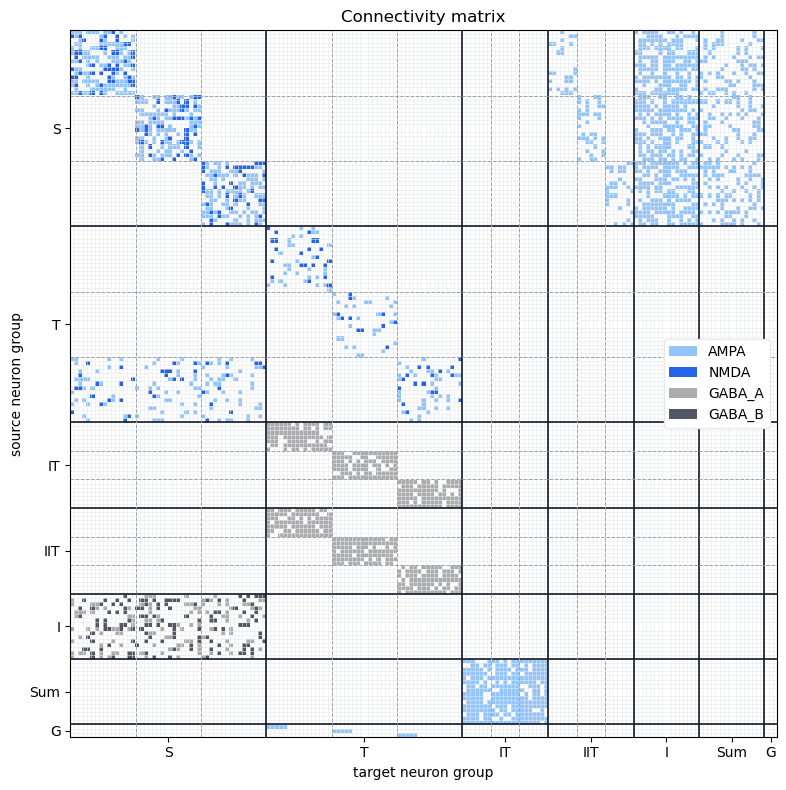

In [16]:
plt.clf()
plt.close('all')

fig, ax = plt.subplots(figsize=(8, 8))


# ------------------------------------------------------------
# DISCRETE SYNAPSE COLORS
# ------------------------------------------------------------
syn_colors = {
    "GABA_B": "#525763",
    "GABA_A": "#acacac",
    "none":   "#ffffff",
    "AMPA":   "#93c5fd",
    "NMDA":   "#2563eb",
}

values = [-2, -1, 0, 1, 2]

colors = [
    syn_colors["GABA_B"],
    syn_colors["GABA_A"],
    syn_colors["none"],
    syn_colors["AMPA"],
    syn_colors["NMDA"],
]

cmap = ListedColormap(colors)

bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
norm   = BoundaryNorm(bounds, cmap.N)

im = ax.imshow(
    C,
    cmap          = cmap,
    norm          = norm,
    interpolation = 'none',
    aspect        = 'equal'
)


# ------------------------------------------------------------
# CELL GRID
# ------------------------------------------------------------
ax.set_xticks(np.arange(N_tot + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(N_tot + 1) - 0.5, minor=True)

ax.grid(
    which     = 'minor',
    color     = '#e5e7eb',
    linestyle = '-',
    linewidth = 0.4
)

ax.tick_params(which='minor', bottom=False, left=False)


# ------------------------------------------------------------
# GROUP BOUNDARIES
# ------------------------------------------------------------
group_specs = [
    ("S",   NS * NE),
    ("T",   NS * NT),
    ("IT",  NS * NIT),
    ("IIT", NS * NIIT),
    ("I",   NI),
    ("Sum", NSum),
    ("G", NS),
]

group_sizes  = [size for _, size in group_specs]
group_labels = [name for name, _ in group_specs]

boundaries = np.cumsum(group_sizes)

boundary_color = "#111827"

for b in boundaries[:-1]:
    ax.axhline(b - 0.5, color=boundary_color, linewidth=1.2)
    ax.axvline(b - 0.5, color=boundary_color, linewidth=1.2)


# ------------------------------------------------------------
# OPTIONAL: INTERNAL SUBPOPULATION BOUNDARIES
# ------------------------------------------------------------
sub_boundary_color = "#9ca3af"

start = 0

for name, size in group_specs:

    if name == "S":
        pop_size = NE
        n_pop    = NS
    elif name == "T":
        pop_size = NT
        n_pop    = NS
    elif name == "IT":
        pop_size = NIT
        n_pop    = NS
    elif name == "IIT":
        pop_size = NIIT
        n_pop    = NS
    else:
        start += size
        continue

    for p in range(1, int(n_pop)):
        b = start + p * pop_size

        ax.axhline(b - 0.5, color=sub_boundary_color, linewidth=0.7, linestyle='--')
        ax.axvline(b - 0.5, color=sub_boundary_color, linewidth=0.7, linestyle='--')

    start += size


# ------------------------------------------------------------
# GROUP LABELS
# ------------------------------------------------------------
centers = np.cumsum(group_sizes) - np.array(group_sizes) / 2 - 0.5

ax.set_xticks(centers)
ax.set_yticks(centers)

ax.set_xticklabels(group_labels)
ax.set_yticklabels(group_labels)

ax.set_xlabel("target neuron group")
ax.set_ylabel("source neuron group")
ax.set_title("Connectivity matrix")


# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
legend_elements = [
    Patch(facecolor=syn_colors["AMPA"],   edgecolor='none', label='AMPA'),
    Patch(facecolor=syn_colors["NMDA"],   edgecolor='none', label='NMDA'),
    Patch(facecolor=syn_colors["GABA_A"], edgecolor='none', label='GABA_A'),
    Patch(facecolor=syn_colors["GABA_B"], edgecolor='none', label='GABA_B'),
]

ax.legend(
    handles    = legend_elements,
    loc        = 'center right',
    frameon    = True,
    framealpha = 1.0,
    edgecolor  = '#e5e7eb'
)

plt.tight_layout()
plt.show()

In [17]:
# ------------------------------------------------------------
# APPLY CONFIGURATION
# ------------------------------------------------------------
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)

set_params(model, param_group=param_group0) # TODO

# ------------------------------------------------------------
# PREPARE POISSON INPUT
# ------------------------------------------------------------
global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
poisson_gen            = model.get_poisson_gen()
poisson_gen.set_chip_id(0)

# set initial rates to zero
for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

# ------------------------------------------------------------
# MONITOR NEURONS
# ------------------------------------------------------------

monitored_neurons = (
    S_ids
    + T_ids
    + IT_ids
    + IIT_ids
    + I_ids
    + Sum_ids
)

graph, filter_node, sink_node = ut.create_neuron_select_graph(
    model,
    monitored_neurons
)

graph.start()

# clear buffer
sink_node.get_events()
api.reset_timestamp()

### **Create Input Spike-Train**

In [18]:
# ------------------------------------------------------------
# CREATE POISSON SPIKE TIMES
# ------------------------------------------------------------
spike_times  = []
indices      = []
target_chips = []

t0 = 0.0

for i, duration in enumerate(t_steps_stim):

    for gen_id, rate in zip(global_poisson_gen_ids, stim_rates_hz[i]):

        n_spikes = np.random.poisson(rate * duration)
        
        times = t0 + np.sort(np.random.rand(n_spikes) * duration)
        
        spike_times.extend(times)
        indices.extend([gen_id] * n_spikes)
        target_chips.extend([0] * n_spikes)

    t0 += duration


# Then sort all spikes globally in time:
spike_times  = np.array(spike_times)
indices      = np.array(indices)
target_chips = np.array(target_chips)

sort_idx = np.argsort(spike_times)

spike_times  = spike_times[sort_idx]
indices      = indices[sort_idx]
target_chips = target_chips[sort_idx]


# Then load the stimulus:
fpga_spike_gen = model.get_fpga_spike_gen()

ut.set_fpga_spike_gen(
    fpga_spike_gen = fpga_spike_gen,
    spike_times    = spike_times,
    indices        = indices,
    target_chips   = target_chips,
    isi_base       = 900,
    repeat_mode    = False
)

RepeatMode already 0


In [19]:

# ------------------------------------------------------------
# INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
activity_dt_s = 0.2
exp_tc_s      = 0.02


def population_activity(t_spikes, n_neurons):
    t_spikes = np.asarray(t_spikes, dtype=float)
    t_spikes = np.sort(t_spikes[(t_spikes >= 0) & (t_spikes < t_tot)])

    if len(t_spikes) == 0:
        activity_x    = np.arange(0, t_tot, activity_dt_s)
        activity_rate = np.zeros_like(activity_x)
        return activity_rate, activity_x

    activity_hz, activity_x = get_instantaneous_activity(
        t_spikes,
        activity_dt_s,
        exp_tc_s
    )

    activity_hz = np.asarray(activity_hz, dtype=float)
    activity_x  = np.asarray(activity_x, dtype=float)

    mask = activity_x < t_tot

    activity_rate = activity_hz[mask] / n_neurons
    activity_x    = activity_x[mask]

    return activity_rate, activity_x


### **Plot Stimulation Rates**

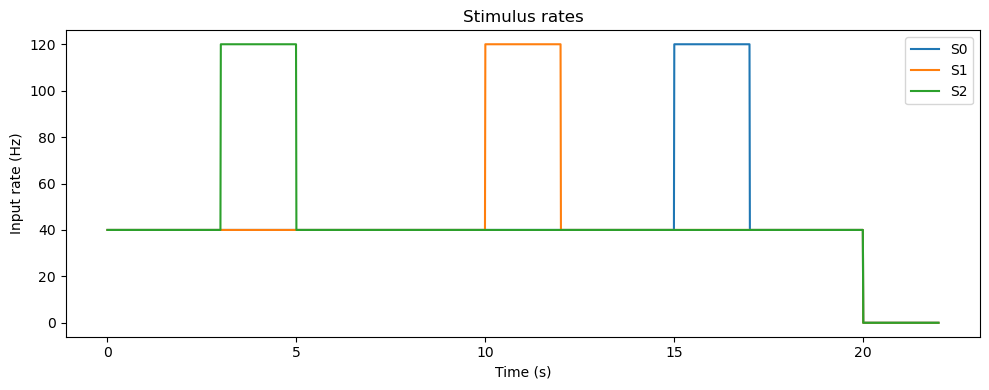

In [20]:

fs = 100

stim_rates_hz = np.array(stim_rates_hz)
t             = np.arange(0, t_tot, 1/fs)

# allocate rate matrix
rates = np.zeros((NS, len(t)))

# fill piecewise constant segments
t_cursor = 0
for i, dt in enumerate(t_steps_stim):
    idx_start = int(t_cursor * fs)
    idx_end   = int((t_cursor + dt) * fs)

    for s in range(NS):
        rates[s, idx_start:idx_end] = stim_rates_hz[i, s]

    t_cursor += dt

plt.figure(figsize=(10,4))

for s in range(NS):
    plt.plot(t, rates[s], label=f"S{s}")

plt.xlabel("Time (s)")
plt.ylabel("Input rate (Hz)")
plt.title("Stimulus rates")
plt.legend()
plt.tight_layout()
plt.show()


### **Run Simulation**

In [21]:
# Run Simulation
fpga_spike_gen.start()
time.sleep(t0)
fpga_spike_gen.stop()

# turn off stimulus

for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

poisson_gen.stop()
time.sleep(t_tot)

graph.stop()
events = sink_node.get_events()

print(f"{len(events)} events recorded.")

PoissonGen already off!
193 events recorded.


### **Post Simulation Processing**

In [22]:
# ------------------------------------------------------------
# EXTRACT EVENTS
# ------------------------------------------------------------
spike_id = []
spike_t  = []

for evt in events:
    spike_id.append(evt.neuron_id)
    spike_t.append(evt.timestamp * 1e-6)

spike_id = np.array(spike_id)
spike_t  = np.array(spike_t)


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def split_population(spike_id, spike_t, start_id, n_pops, pop_size):
    pop_spike_id = []
    pop_spike_t  = []

    for p in range(int(n_pops)):
        lo = start_id + p * pop_size
        hi = lo + pop_size

        mask = (spike_id >= lo) & (spike_id < hi)

        pop_spike_id.append(spike_id[mask])
        pop_spike_t.append(spike_t[mask])

    return pop_spike_id, pop_spike_t


def filter_population(spike_id, spike_t, start_id, stop_id):
    mask = (spike_id >= start_id) & (spike_id < stop_id)

    return spike_id[mask], spike_t[mask]

In [23]:
# ------------------------------------------------------------
# FILTER SPIKES BY POPULATION GROUP
# ------------------------------------------------------------
S_spike_id, S_spike_t = split_population(
    spike_id,
    spike_t,
    start_id = 1,
    n_pops   = NS,
    pop_size = NE
)

T_spike_id, T_spike_t = split_population(
    spike_id,
    spike_t,
    start_id = next_neuron_ids[0],
    n_pops   = NS,
    pop_size = NT
)

IT_spike_id, IT_spike_t = split_population(
    spike_id,
    spike_t,
    start_id = next_neuron_ids[1],
    n_pops   = NS,
    pop_size = NIT
)

IIT_spike_id, IIT_spike_t = split_population(
    spike_id,
    spike_t,
    start_id = next_neuron_ids[2],
    n_pops   = NS,
    pop_size = NIIT
)


I_spike_id, I_spike_t = filter_population(
    spike_id,
    spike_t,
    start_id = next_neuron_ids[3],
    stop_id  = next_neuron_ids[4]
)


Sum_mask = spike_id >= next_neuron_ids[4]

Sum_spike_id = spike_id[Sum_mask]
Sum_spike_t  = spike_t[Sum_mask]

In [24]:
# ------------------------------------------------------------
# COLORS
# ------------------------------------------------------------

colors_S = [
    "#93c5fd",
    "#60a5fa",
    "#2563eb",
    "#1e3a8a",  # dark blue
    "#dbeafe",  # very light blue

]

colors_T = [
    "#86efac",
    "#4ade80",
    "#16a34a",
    "#14532d",  # dark green    
    "#dcfce7",  # very light green

]

colors_IT = [
    "#d8b4fe",
    "#c084fc",
    "#9333ea",
    "#581c87",  # dark purple
    "#f3e8ff",  # very light purpl
]

colors_IIT = [
    "#fca5a5",
    "#f87171",
    "#dc2626",
    "#7f1d1d",  # dark red
    "#fee2e2",  # very light red

]

color_I   = "#7F848F"  # dark grey-blue
color_Sum = "#111827"  # near-black

color_in = "#111827"  # near-black

def get_color(colors, idx):
    return colors[idx % len(colors)]

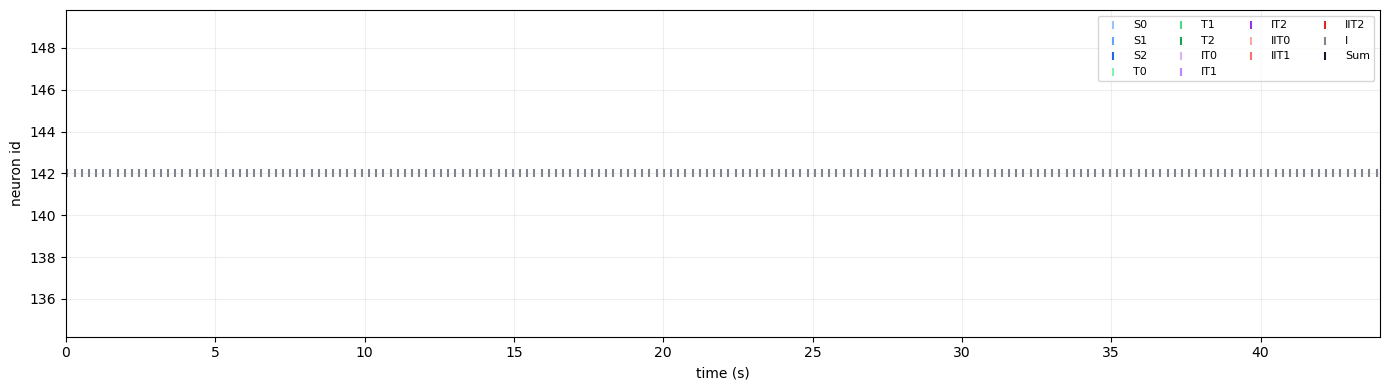

In [25]:
# ------------------------------------------------------------
# PLOT RASTER
# ------------------------------------------------------------
plt.figure(figsize=(14, 4))

for s in range(int(NS)):
    plt.scatter(
        S_spike_t[s],
        S_spike_id[s],
        marker = '|',
        s      = 30,
        color  = get_color(colors_S, s),
        label  = f'S{s}'
    )

for t in range(int(NS)):
    plt.scatter(
        T_spike_t[t],
        T_spike_id[t],
        marker = '|',
        s      = 30,
        color  = get_color(colors_T, t),
        label  = f'T{t}'
    )

for i in range(int(NS)):
    plt.scatter(
        IT_spike_t[i],
        IT_spike_id[i],
        marker = '|',
        s      = 30,
        color  = get_color(colors_IT, i),
        label  = f'IT{i}'
    )

for i in range(int(NS)):
    plt.scatter(
        IIT_spike_t[i],
        IIT_spike_id[i],
        marker = '|',
        s      = 30,
        color  = get_color(colors_IIT, i),
        label  = f'IIT{i}'
    )

plt.scatter(
    I_spike_t,
    I_spike_id,
    marker = '|',
    s      = 30,
    color  = color_I,
    label  = 'I'
)

plt.scatter(
    Sum_spike_t,
    Sum_spike_id,
    marker = '|',
    s      = 30,
    color  = color_Sum,
    label  = 'Sum'
)

plt.xlabel("time (s)")
plt.ylabel("neuron id")
plt.legend(ncol=4, fontsize=8)
plt.grid(True, alpha=0.2)
plt.xlim(0, 2*t_tot)

plt.tight_layout()
plt.show()

In [26]:
# ------------------------------------------------------------
# HELPER
# ------------------------------------------------------------
def compute_group_activity(spike_t_group, n_neurons):
    activity_rate = []
    activity_x    = []

    for spike_times in spike_t_group:
        rate, x = population_activity(spike_times, n_neurons)

        activity_rate.append(rate)
        activity_x.append(x)

    return activity_rate, activity_x


# ------------------------------------------------------------
# COMPUTE POPULATION ACTIVITY
# ------------------------------------------------------------
S_activity_rate,   S_activity_x   = compute_group_activity(S_spike_t,   NE)
T_activity_rate,   T_activity_x   = compute_group_activity(T_spike_t,   NT)
IT_activity_rate,  IT_activity_x  = compute_group_activity(IT_spike_t,  NIT)
IIT_activity_rate, IIT_activity_x = compute_group_activity(IIT_spike_t, NIIT)

I_activity_rate,   I_activity_x   = population_activity(I_spike_t, NI)
Sum_activity_rate, Sum_activity_x = population_activity(Sum_spike_t, NSum)

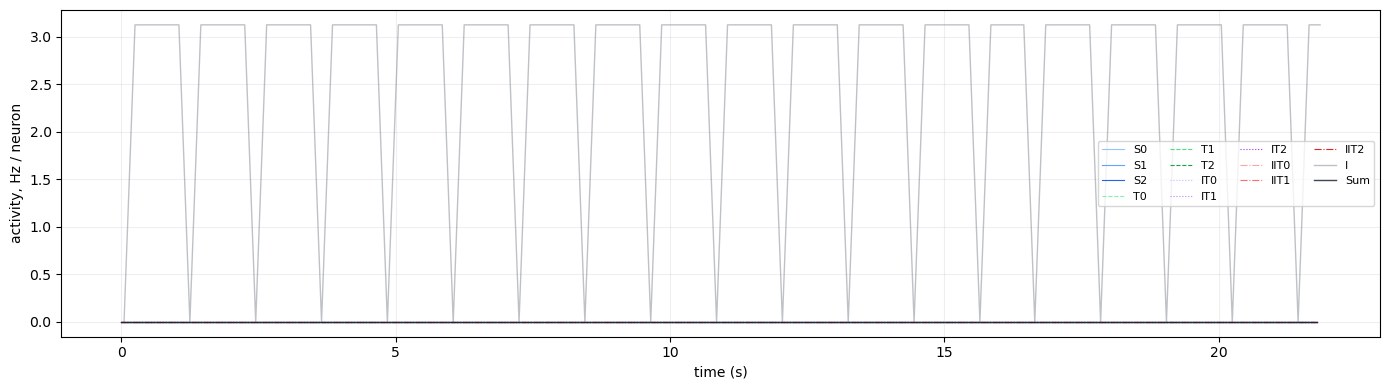

In [27]:
# ------------------------------------------------------------
# PLOT POPULATION ACTIVITY
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 4))

for s in range(int(NS)):
    ax.plot(
        S_activity_x[s],
        S_activity_rate[s],
        linewidth = 0.8,
        color     = get_color(colors_S, s),
        label     = f"S{s}"
    )

for t in range(int(NS)):
    ax.plot(
        T_activity_x[t],
        T_activity_rate[t],
        linewidth = 0.8,
        linestyle = "--",
        color     = get_color(colors_T, t),
        label     = f"T{t}"
    )

for i in range(int(NS)):
    ax.plot(
        IT_activity_x[i],
        IT_activity_rate[i],
        linewidth = 0.8,
        linestyle = ":",
        color     = get_color(colors_IT, i),
        label     = f"IT{i}"
    )

for i in range(int(NS)):
    ax.plot(
        IIT_activity_x[i],
        IIT_activity_rate[i],
        linewidth = 0.8,
        linestyle = "-.",
        color     = get_color(colors_IIT, i),
        label     = f"IIT{i}"
    )

ax.plot(
    I_activity_x,
    I_activity_rate,
    linewidth = 1.0,
    color     = color_I,
    alpha     = 0.5,
    label     = "I"
)

ax.plot(
    Sum_activity_x,
    Sum_activity_rate,
    linewidth = 1.0,
    color     = color_Sum,
    alpha     = 0.8,
    label     = "Sum"
)

ax.set_xlabel("time (s)")
ax.set_ylabel("activity, Hz / neuron")
ax.grid(True, alpha=0.2)
ax.legend(ncol=4, fontsize=8)

plt.tight_layout()
plt.show()

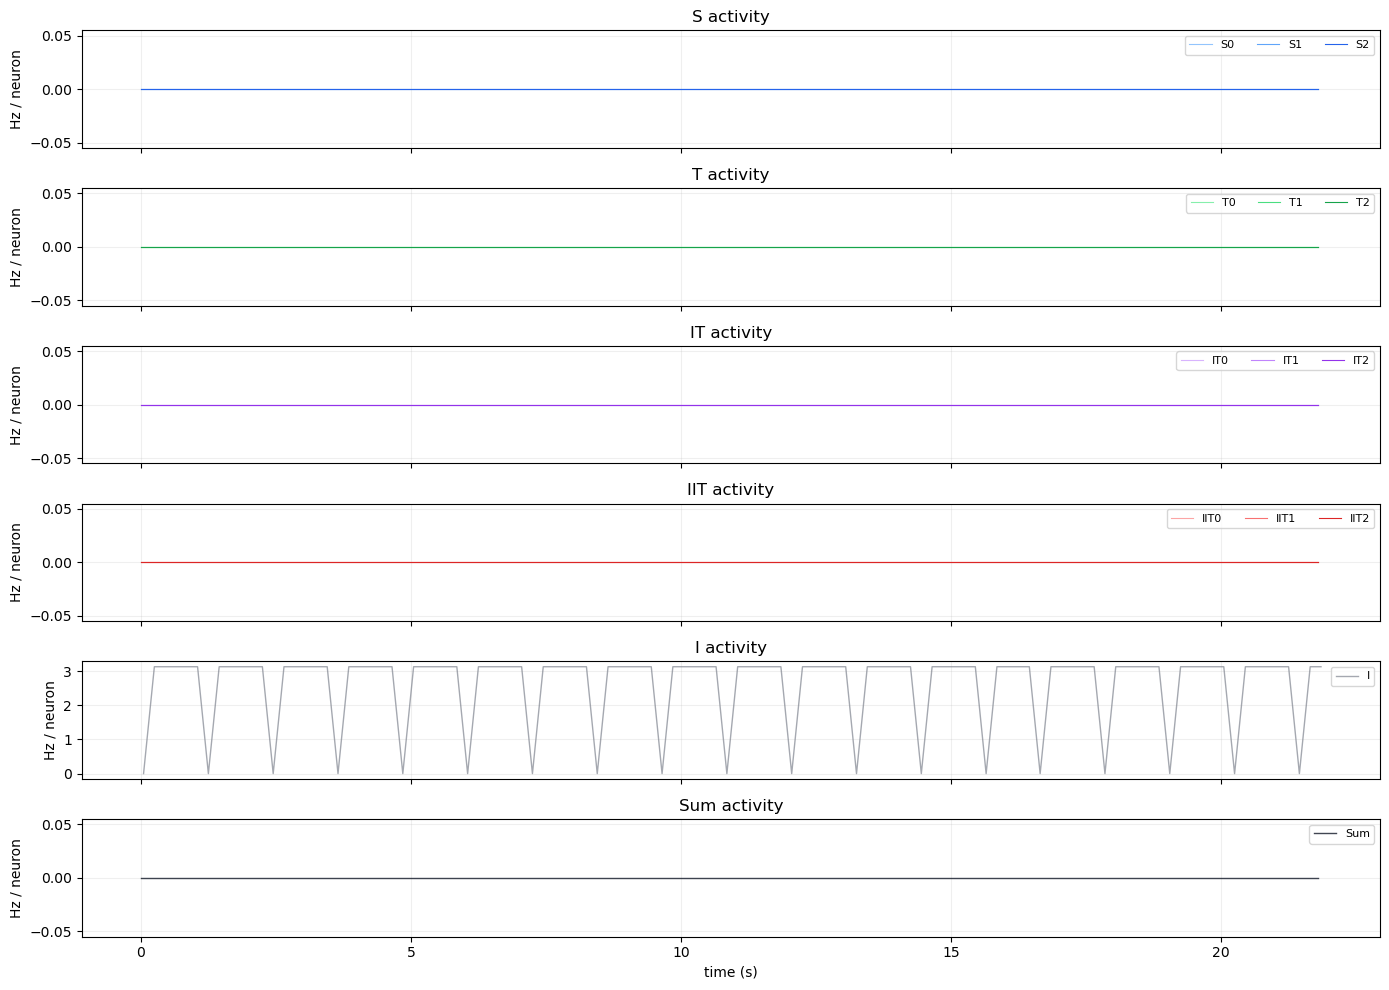

In [28]:
# ------------------------------------------------------------
# PLOT POPULATION ACTIVITY IN STACKED SUBPLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(
    6, 1,
    figsize=(14, 10),
    sharex=True
)

pop_data = [
    ("S",   S_activity_x,   S_activity_rate,   NS, colors_S,   "-"),
    ("T",   T_activity_x,   T_activity_rate,   NS, colors_T,   "-"),
    ("IT",  IT_activity_x,  IT_activity_rate,  NS, colors_IT,  "-"),
    ("IIT", IIT_activity_x, IIT_activity_rate, NS, colors_IIT, "-"),
]

for ax, (name, x_list, rate_list, n_pop, colors, linestyle) in zip(axes[:4], pop_data):

    for i in range(int(n_pop)):
        ax.plot(
            x_list[i],
            rate_list[i],
            linewidth = 0.8,
            linestyle = linestyle,
            color     = get_color(colors, i),
            label     = f"{name}{i}"
        )

    ax.set_ylabel("Hz / neuron")
    ax.set_title(f"{name} activity")
    ax.grid(True, alpha=0.2)
    ax.legend(ncol=4, fontsize=8)


axes[4].plot(
    I_activity_x,
    I_activity_rate,
    linewidth = 1.0,
    color     = color_I,
    alpha     = 0.7,
    label     = "I"
)

axes[4].set_title("I activity")
axes[4].set_ylabel("Hz / neuron")
axes[4].grid(True, alpha=0.2)
axes[4].legend(fontsize=8)


axes[5].plot(
    Sum_activity_x,
    Sum_activity_rate,
    linewidth = 1.0,
    color     = color_Sum,
    alpha     = 0.8,
    label     = "Sum"
)

axes[5].set_title("Sum activity")
axes[5].set_ylabel("Hz / neuron")
axes[5].set_xlabel("time (s)")
axes[5].grid(True, alpha=0.2)
axes[5].legend(fontsize=8)

plt.tight_layout()
plt.show()

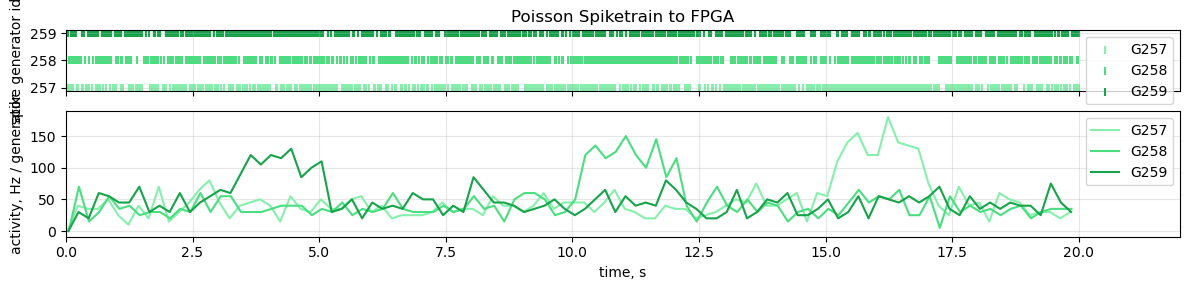

In [29]:
input_spike_t  = np.asarray(spike_times)
input_spike_id = np.asarray(indices)

# ------------------------------------------------------------
# COMPUTE INPUT GENERATOR ACTIVITY
# ------------------------------------------------------------
G_activity_rate = []
G_activity_x    = []
G_ids           = np.unique(input_spike_id)

for gid in G_ids:
    mask = input_spike_id == gid
    rate, x = population_activity(input_spike_t[mask], n_neurons=10)

    G_activity_rate.append(rate)
    G_activity_x.append(x)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 3),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 2.5]}
)

# ------------------------------------------------------------
# RASTER
# ------------------------------------------------------------
for k, gid in enumerate(G_ids):
    mask = input_spike_id == gid

    ax1.scatter(
        input_spike_t[mask],
        input_spike_id[mask],
        marker='|',
        s=30,
        color=colors_T[k],
        label=f'G{gid}'
    )

ax1.set_ylabel('spike generator id')
ax1.set_title('Poisson Spiketrain to FPGA')

ax1.set_yticks(G_ids)
ax1.set_yticklabels([str(int(gid)) for gid in G_ids])

ax1.grid(True, alpha=0.3)
ax1.legend()

# ------------------------------------------------------------
# INSTANTANEOUS ACTIVITY
# ------------------------------------------------------------
for k, gid in enumerate(G_ids):
    ax2.plot(
        G_activity_x[k],
        G_activity_rate[k],
        linestyle='-',
        color=colors_T[k],
        label=f'G{gid}'
    )

ax2.set_xlabel('time, s')
ax2.set_ylabel('activity, Hz / generator')
ax2.set_xlim(0, t_tot)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()